* Course Name: DSC680-T301 Applied Data Science (2271-1)
* Assignment Name: Week 3.1 Project 1 Draft/Milestone 2
* Project Name: Credit Card Fraud Detection
* Student Name: Chunmei Ruan

# Milestone 2 Draft White Paper

## 1 Business Background

### 1.1 Business Problem

Credit card fraud remains one of the most pressing challenges in the financial industry today. With the rise of online transactions and digital payments, the opportunities for fraudulent activities have expanded rapidly, posing severe risks to both consumers and financial institutions. Fraudulent transactions can result in substantial financial losses, legal complications, and significant damage to an organization’s reputation and customer trust. Detecting these fraudulent activities early is therefore essential to maintaining financial security and operational integrity.<br>

However, identifying fraud is inherently difficult because fraudulent transactions are infrequent compared to legitimate ones, resulting in a highly imbalanced dataset. In most real-world cases, less than one percent of all transactions are fraudulent. This imbalance poses a challenge to traditional statistical models, which tend to be biased toward predicting the majority class (legitimate transactions). Consequently, the development of robust fraud detection systems requires not only advanced analytical methods but also effective strategies to handle class imbalance and optimize predictive performance.<br>

This study focuses on performing an in-depth exploratory data analysis (EDA) of a credit card transaction dataset to uncover valuable insights and patterns that distinguish legitimate transactions from fraudulent ones. Various statistical techniques and visualization methods are employed to explore relationships between anonymized features, transaction amounts, and transaction times. These steps provide a crucial foundation for building and evaluating predictive models that can identify potential fraud in real-time.<br>

To address this business problem effectively, machine learning models such as Logistic Regression and Random Forest are applied. Logistic Regression is utilized for its interpretability and effectiveness in binary classification tasks, offering insight into how specific features influence the likelihood of fraudulent transactions. Conversely, the Random Forest model, an ensemble-based method, is employed to capture complex, nonlinear relationships and interactions within the data. By comparing model performance using evaluation metrics such as accuracy, precision, recall, F1-score, and the area under the ROC curve (AUC), this study aims to determine the most suitable predictive model for operational deployment.<br>


### 1.2 Data and Methods

* Business Problem:<br>
Credit card fraud poses a major risk to financial institutions, resulting in significant financial losses and reputational harm. Detecting fraudulent transactions is challenging because fraud cases are extremely rare compared to legitimate transactions, leading to class imbalance in the data.

* Analytical Objective:<br>
The goal of this project is to build a predictive model capable of accurately identifying fraudulent transactions while minimizing false positives. The model will support fraud prevention systems by improving the speed and accuracy of fraud detection.

* Modeling Approach:<br>
Two supervised machine learning models—Logistic Regression and Random Forest Classification—are developed and compared to determine which provides the best balance of precision, recall, and interpretability.

* Target Variable:<br>
The “Class” column serves as the target variable:
1 = Fraudulent transaction
0 = Legitimate transaction

* Predictor Variables:<br>
The input features include anonymized numerical variables that describe transaction behavior, as well as transaction amount and transaction time.

* Expected Outcome:<br>
The model aims to enhance the detection of high-risk transactions, reduce financial losses, and improve customer trust through data-driven fraud prevention strategies.

### 1.3 Data Explanation

#### 1.3.1 Dataset Selection and Import Dataset

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics 

In [2]:
# 'Credit Card Fraud Detection' dataset from data sources Kaggle 
# Load the dataset file to Pandas DataFrame called 'credit'
credit = pd.read_csv('C:/Users/MAYMA/Downloads/Bellevue_University/dsc530miniconda/envs/book_env/DSC680-T301-Applied-Data-Science/Dataset/creditcard.csv')


In [3]:
# Preview the column names, counts and the data types
print(credit.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
# Display the first 10 rows of the data set
print("\nThe first ten rows of data:")
print(credit.head(10))



The first ten rows of data:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   
5   2.0 -0.425966  0.960523  1.141109 -0.168252  0.420987 -0.029728  0.476201   
6   4.0  1.229658  0.141004  0.045371  1.202613  0.191881  0.272708 -0.005159   
7   7.0 -0.644269  1.417964  1.074380 -0.492199  0.948934  0.428118  1.120631   
8   7.0 -0.894286  0.286157 -0.113192 -0.271526  2.669599  3.721818  0.370145   
9   9.0 -0.338262  1.119593  1.044367 -0.222187  0.499361 -0.246761  0.651583   

         V8        V9  ...       V21       V22       V23       V24       V25  \

#### 1.3.2 Data Cleaning and Preparation

Handle missing values

In [5]:
# Check for missing values
print(credit.isnull().sum()) 

# No missing values in this dataset so no action needed

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Normalization

In [6]:
# Numerical variables V1-V28 have already been scaled.
# The rest of the numerical variables, Amount and Time, need to be scaled in this dataset.

# Import library
from sklearn.preprocessing import StandardScaler, RobustScaler

# Using StandardScaler() to standardize only 'Amount' and 'Time'

# Create standard scaler
std_scaler = StandardScaler()
# RobustScaler is less prone to outliers.
rob_scaler = RobustScaler()


# Using copy() to make a copy of the original dataframe
credit_scaled = credit.copy()


credit_scaled['Amount'] = rob_scaler.fit_transform(credit_scaled['Amount'].values.reshape(-1,1))
credit_scaled['Time'] = rob_scaler.fit_transform(credit_scaled['Time'].values.reshape(-1,1))


# Preview the random 10 rows of the standardized data set
print(credit_scaled.sample(10,random_state=1))

            Time        V1        V2        V3        V4        V5        V6  \
169876  0.413715 -0.611712 -0.769705 -0.149759 -0.224877  2.028577 -2.019887   
127467 -0.074625 -0.814682  1.319219  1.329415  0.027273 -0.284871 -0.653985   
137900 -0.027138 -0.318193  1.118618  0.969864 -0.127052  0.569563 -0.532484   
21513  -0.622364 -1.328271  1.018378  1.775426 -1.574193 -0.117696 -0.457733   
134700 -0.044279  1.276712  0.617120 -0.578014  0.879173  0.061706 -1.472002   
196117  0.548315  0.077197  0.482928 -2.234233 -1.309124  2.386570  3.392581   
24533  -0.604072 -0.958584  1.109086  1.558159  0.878707  1.914559  1.564757   
13629  -0.711169 -0.992899  1.430204  1.071256  1.363127  0.116315  0.217868   
246673  0.805743 -1.143693 -0.250983  1.013022 -0.671080  1.363438  0.312673   
91842  -0.247219  0.555043 -0.099484 -0.102234 -0.624145  1.484364  4.154536   

              V7        V8        V9  ...       V21       V22       V23  \
169876  0.292491 -0.523020  0.358468  ... -0

### 1.4 Graphical analysis

#### 1.4.1 Graphical analysis - Histogram Plot

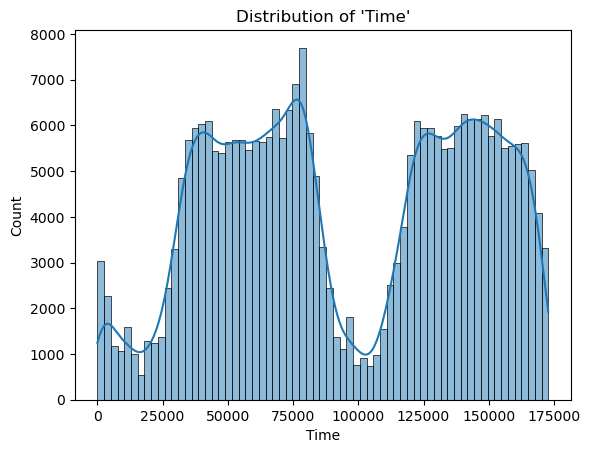

In [7]:
# Import library
import seaborn as sns

# Using seaborn to create a histogram plot for 'Time'
sns.histplot(credit['Time'], kde=True)
plt.title("Distribution of 'Time'")
plt.show()

Histogram Plot Explanation<br>
* Bimodal Shape: The histogram shows two distinct peaks—one around 50,000 and another near 125,000—indicating that transactions tend to cluster in two separate time windows. This could reflect different user activity periods, system batch processing times, or regional time zones.
* Dip in the Middle: There is a noticeable drop in transaction frequency around 90,000, suggesting a lull or off-peak period in transaction activity.

#### 1.4.2 Graphical analysis - Bar chart

In [8]:
# Using value_counts() to count the number of 0 and 1 in the Class column
class_counts = credit['Class'].value_counts().sort_index()
total = class_counts.sum()


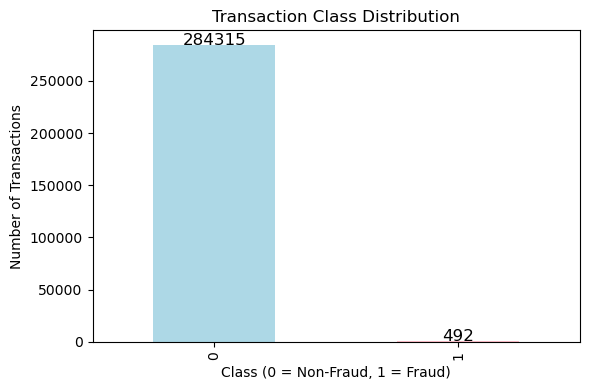

In [9]:
# Using plot(kind='bar') to create a bar chart
class_counts.plot(kind='bar', color=['lightblue', 'pink'], figsize=(6, 4))

# Add labels and title to the bar chart
plt.title("Transaction Class Distribution")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")

# Using plt.text() to add value labels on top of bars
for i, count in enumerate(class_counts.values):
    plt.text(i, count + 200, str(count), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

Bar Chart Explanation<br>
The chart shows that there are 284,315 non-fraudulent (Class 0) transactions compared to only 492 fraudulent (Class 1) transactions. The fraudulent transactions make up less than 0.2% of all records. The bar chart highlights the need for class balancing techniques for the machine learning model.

#### 1.4.3 Graphical analysis - Heat map

In [10]:
# Exclude 'Class' to compute Pearson correlation on continuous variables only
continuous_vars = credit_scaled.drop(columns='Class')

# Using corr() to calculate correlation matrix 
correlation_matrix = continuous_vars.corr(method='pearson')


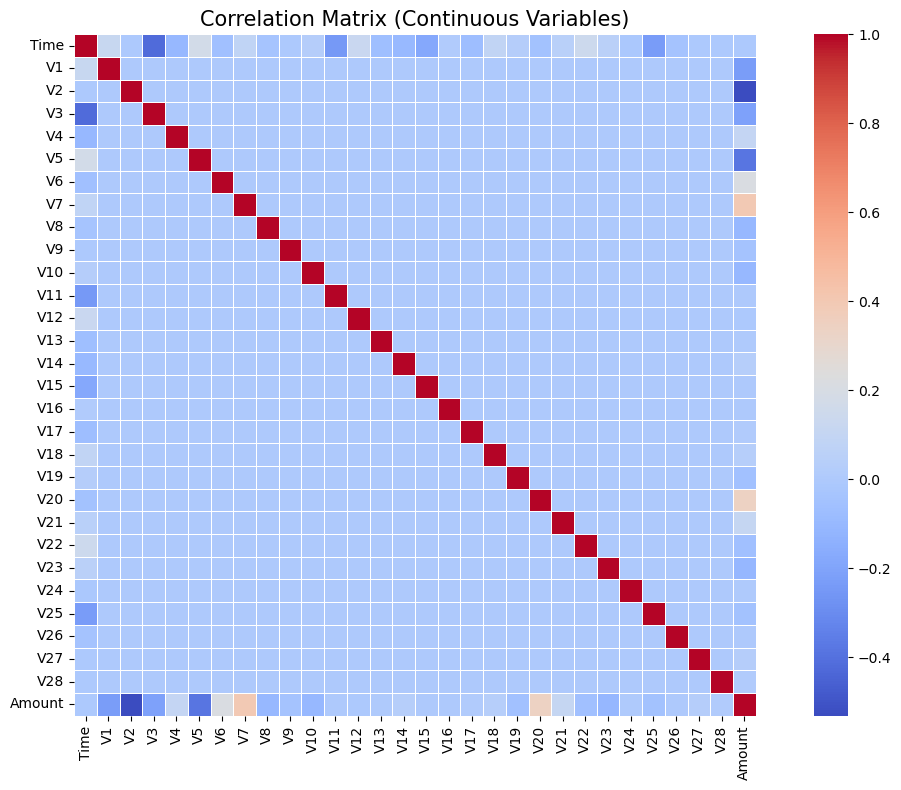

In [11]:
# Set plot size and style and using seaborn to create a heatmap 
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", square=True, linewidths=0.5)
plt.title('Correlation Matrix (Continuous Variables)', fontsize=15)
plt.tight_layout()
plt.show()


Heat Map Explanation<br>
Most of the off-diagonal values are light blue, indicating low or weak correlations among most features.
This correlation matrix confirms that the dataset’s features are mostly independent, meaning each contributes unique information. This is beneficial for machine learning models such as logistic regression or random forest, as it prevents redundancy and enhances the model’s ability to capture meaningful patterns for fraud detection.

#### 1.4.4 Graphical analysis - Scatter Plot

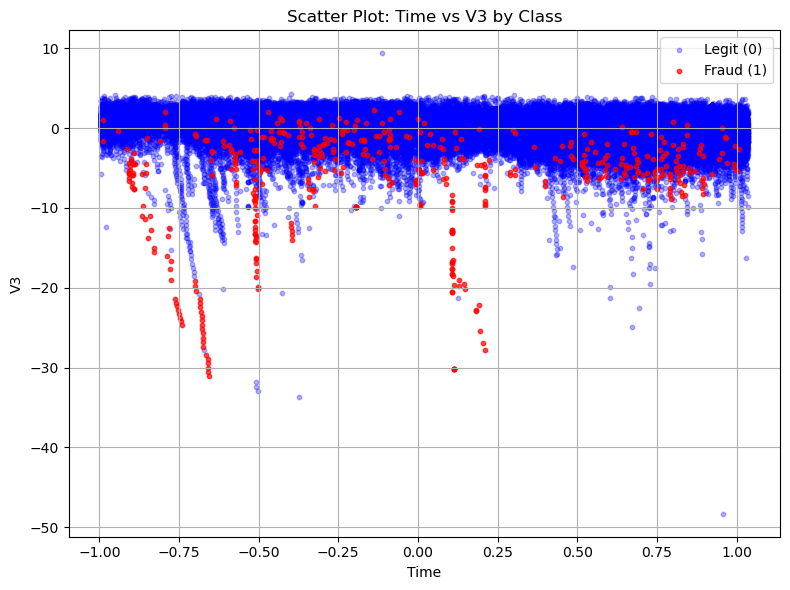

In [12]:
# Select two continuous variables from the heat map with higher Correlation Matrix
x_var = 'Time'
y_var = 'V3'

# Using matplotlib to create a scatter plot
# Use different colors for fraud (1) and non-fraud (0)
plt.figure(figsize=(8, 6))
plt.scatter(
    credit_scaled[credit_scaled['Class'] == 0][x_var],
    credit_scaled[credit_scaled['Class'] == 0][y_var],
    label='Legit (0)', alpha=0.3, s=10, c='blue'
)
plt.scatter(
    credit_scaled[credit_scaled['Class'] == 1][x_var],
    credit_scaled[credit_scaled['Class'] == 1][y_var],
    label='Fraud (1)', alpha=0.7, s=10, c='red'
)
plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f'Scatter Plot: {x_var} vs {y_var} by Class')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Scatter Plot Explanation<br>
Legitimate transactions (blue) are densely clustered, characterized by higher V3 values and consistent timing. In contrast, fraudulent ones (red) are sparse, often show lower V3 values below -10, and occasionally form time-based clusters suggestive of coordinated activity.

### 1.5 Insights gained graphical analysis

The visual exploration of the dataset reveals several key patterns that inform the modeling strategy. The class distribution chart highlights a severe imbalance, with fraudulent transactions comprising less than 0.2% of the data—underscoring the need for techniques that address minority class detection. The scatter plots of Time vs. V3 show that fraudulent transactions tend to cluster around extreme negative V3 values, suggesting that V3 is a strong candidate for distinguishing between fraudulent and non-fraudulent transactions. The distribution of Time is bimodal, indicating two distinct transaction periods, which may reflect behavioral shifts or system-level patterns. Finally, the correlation matrix shows minimal multicollinearity among features, supporting the use of all predictors in model training without significant redundancy.

To move forward, consider implementing data balancing techniques, such as SMOTE (Synthetic Minority Over-sampling Technique) or cost-sensitive learning, to mitigate class imbalance. Then, evaluate both Logistic Regression and Random Forest models using precision, recall, F1-score, and ROC-AUC, with a special focus on recall for fraud detection. Feature importance analysis—especially for V3 and Time—can guide interpretability and refine the model.

## 2 Data Analysis

In [13]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
# Preview the original dataset
print(credit.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [15]:
# Preview the first 5 rows of the original dataset
print(credit.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

### 2.1 Data Cleaning

In [16]:
# Copy data to avoid modifying original
credit2 = credit.copy()

In [17]:

# Using corr() to compute correlation matrix
corr_matrix = credit2.corr()

# Display numeric correlation matrix with round values for readability
corr_rounded = corr_matrix.round(5)
print("\nRounded Correlation Matrix:")
print(corr_rounded)



Rounded Correlation Matrix:
           Time       V1       V2       V3       V4       V5       V6  \
Time    1.00000  0.11740 -0.01059 -0.41962 -0.10526  0.17307 -0.06302   
V1      0.11740  1.00000  0.00000 -0.00000 -0.00000  0.00000 -0.00000   
V2     -0.01059  0.00000  1.00000  0.00000 -0.00000  0.00000  0.00000   
V3     -0.41962 -0.00000  0.00000  1.00000  0.00000 -0.00000  0.00000   
V4     -0.10526 -0.00000 -0.00000  0.00000  1.00000 -0.00000 -0.00000   
V5      0.17307  0.00000  0.00000 -0.00000 -0.00000  1.00000  0.00000   
V6     -0.06302 -0.00000  0.00000  0.00000 -0.00000  0.00000  1.00000   
V7      0.08471 -0.00000  0.00000  0.00000 -0.00000  0.00000  0.00000   
V8     -0.03695 -0.00000 -0.00000 -0.00000  0.00000  0.00000 -0.00000   
V9     -0.00866 -0.00000  0.00000  0.00000  0.00000  0.00000  0.00000   
V10     0.03062  0.00000 -0.00000  0.00000  0.00000 -0.00000  0.00000   
V11    -0.24769  0.00000  0.00000  0.00000  0.00000  0.00000  0.00000   
V12     0.12435  0.000



The time column represents the number of seconds since the first transaction — not particularly informative by itself.<br>
It will be transformed into more meaningful time-based features. The time variable will be dropped after feature creation is complete.

### 2.2 Data extraction/selection steps

In [18]:
# Data selection 
# Separate target variable
X = credit2.drop(columns=['Class'])
y = credit2['Class']


### 2.3 Transform features

In [19]:

# Create meaningful time features before dropping 'Time'
# Convert seconds to minutes and hours (0–24 cycle to capture behavioral patterns)
credit2['Minute'] = ((credit2['Time'] / 60) % 1440).round(2)
credit2['Hour'] = ((credit2['Time'] / 3600) % 24).round(2)


In [20]:
# Drop the original Time column after extraction
credit2 = credit2.drop(columns=['Time'])

In [21]:
# Preview the updated dataset
print(credit2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 32 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      284807 non-null  float64
 1   V2      284807 non-null  float64
 2   V3      284807 non-null  float64
 3   V4      284807 non-null  float64
 4   V5      284807 non-null  float64
 5   V6      284807 non-null  float64
 6   V7      284807 non-null  float64
 7   V8      284807 non-null  float64
 8   V9      284807 non-null  float64
 9   V10     284807 non-null  float64
 10  V11     284807 non-null  float64
 11  V12     284807 non-null  float64
 12  V13     284807 non-null  float64
 13  V14     284807 non-null  float64
 14  V15     284807 non-null  float64
 15  V16     284807 non-null  float64
 16  V17     284807 non-null  float64
 17  V18     284807 non-null  float64
 18  V19     284807 non-null  float64
 19  V20     284807 non-null  float64
 20  V21     284807 non-null  float64
 21  V22     28

### 2.4 Engineer new useful features

In [22]:
# Transaction amount interaction terms can help detect abnormal patterns
# Apply a log transformation to the transaction amount, which can help reduce skew
credit2['Amount_log'] = np.log1p(credit2['Amount']) 

# Calculate how large each transaction is relative to the typical (mean) transaction amount
credit2['Amount_to_mean_ratio'] = credit2['Amount'] / credit2['Amount'].mean()

* A log transformation can help reduce skew because fraud datasets often have extreme transaction values. It can make large values less dominant and help models detect unusually high transactions more effectively.<br>
* Fraud often involves transactions that are significantly larger than usual, indicating money laundering or cash draining; however, it can also be much smaller, such as testing stolen cards. This 'Amount_to_mean_ratio' helps identify abnormal behavior.<br>

In [23]:
# Preview the updated dataset
print(credit2.head())

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V25       V26       V27       V28  \
0  0.098698  0.363787  0.090794  ...  0.128539 -0.189115  0.133558 -0.021053   
1  0.085102 -0.255425 -0.166974  ...  0.167170  0.125895 -0.008983  0.014724   
2  0.247676 -1.514654  0.207643  ... -0.327642 -0.139097 -0.055353 -0.059752   
3  0.377436 -1.387024 -0.054952  ...  0.647376 -0.221929  0.062723  0.061458   
4 -0.270533  0.817739  0.753074  ... -0.206010  0.502292  0.219422  0.215153   

   Amount  Class  Minute  Hour  Amount_log  Amount_to_mean_ratio  
0

### 2.5 Check missing data

In [24]:
# Check how many missing values are in each column
missing_counts = credit2.isnull().sum()

# Preview the missing values
print(missing_counts)

V1                      0
V2                      0
V3                      0
V4                      0
V5                      0
V6                      0
V7                      0
V8                      0
V9                      0
V10                     0
V11                     0
V12                     0
V13                     0
V14                     0
V15                     0
V16                     0
V17                     0
V18                     0
V19                     0
V20                     0
V21                     0
V22                     0
V23                     0
V24                     0
V25                     0
V26                     0
V27                     0
V28                     0
Amount                  0
Class                   0
Minute                  0
Hour                    0
Amount_log              0
Amount_to_mean_ratio    0
dtype: int64


Observation of Missing Data

Missing data was assessed using summary statistics.
The analysis indicated that no missing values were present in the dataset, confirming its completeness and readiness for subsequent modeling.
Although no imputation was necessary, visualizing missingness remains a recommended data preprocessing step to validate data integrity and uncover any potential patterns of data absence.

### 2.6 SMOTE Implementation to Mitigate the Class Imbalance

In [25]:
# Import libraries
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


#### 2.6.1 Split the Dataset

In [26]:
# Separate x and y
x = credit2.drop(columns=['Class'])
y = credit2['Class']

In [27]:
# Using train_test_split to split the data
# Using stratify=y to keep the same fraud ratio in both train and test sets.
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Preview the class distribution of the training data set
print("Train Class Distribution:\n", y_train.value_counts())

# Preview the class distribution of the testing data set
print("Test Class Distribution:\n", y_test.value_counts())


Train Class Distribution:
 Class
0    227451
1       394
Name: count, dtype: int64
Test Class Distribution:
 Class
0    56864
1       98
Name: count, dtype: int64


#### 2.6.2 Apply SMOTE to Training Data Only

In [30]:
# Apply SMOTE to the training dataset only with full balancing
sm = SMOTE(random_state=42)
x_train_smote, y_train_smote = sm.fit_resample(x_train, y_train)


In [31]:
# Apply SMOTE to the training dataset only with a smaller SMOTE ratio of 20%
# To avoid overfitting, unrealistic distribution, or too many synthetic frauds of extremely skewed datasets

sm = SMOTE(sampling_strategy=0.2, random_state=42)
x_train_ssmote, y_train_ssmote = sm.fit_resample(x_train, y_train)

#### 2.6.3 Check Class Balance Before & After

In [32]:
# Preview the Original Training data set 
print("Original training set distribution:")
print(y_train.value_counts())

# Preview the Training data set after SMOTE with full balancing
print("\nTraining dataset after SMOTE with full balancing:")
print(y_train_smote.value_counts())

# Preview the Training data set after SMOTE with a 20% SMOTE ratio
print("\nTraining dataset after SMOTE with a 20% ratio:")
print(y_train_ssmote.value_counts())

Original training set distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Training dataset after SMOTE with full balancing:
Class
0    227451
1    227451
Name: count, dtype: int64

Training dataset after SMOTE with a 20% ratio:
Class
0    227451
1     45490
Name: count, dtype: int64


In [33]:
# Preview the feature-engineered dataset
print("Training dataset(SMOTE):", x_train_smote.shape)

# Preview the first 5 rows of the dataset 
print("Preview dataset after SMOTE :")
print(x_train_smote.head())

Training dataset(SMOTE): (454902, 33)
Preview dataset after SMOTE :
         V1        V2        V3        V4        V5        V6        V7  \
0  1.946747 -0.752526 -1.355130 -0.661630  1.502822  4.024933 -1.479661   
1  2.035149 -0.048880 -3.058693  0.247945  2.943487  3.298697 -0.002192   
2 -0.991920  0.603193  0.711976 -0.992425 -0.825838  1.956261 -2.212603   
3  2.285718 -1.500239 -0.747565 -1.668119 -1.394143 -0.350339 -1.427984   
4 -0.448747 -1.011440  0.115903 -3.454854  0.715771 -0.147490  0.504347   

         V8        V9       V10  ...       V24       V25       V26       V27  \
0  1.139880  1.406819 -0.157403  ...  0.690980 -0.350316 -0.388907  0.077641   
1  0.674782  0.045826  0.284864  ...  0.707090  0.512885 -0.471198  0.002520   
2 -5.037523  0.000772 -2.009561  ... -0.932803  0.826684  0.913773  0.038049   
3  0.010010 -1.118447  1.756121  ... -0.538236 -0.278032 -0.162068  0.018045   
4 -0.113817 -0.044782 -0.558955  ... -1.362383 -0.292234 -0.144622 -0.032580   



## 3 Model Building and Evaluation

In [34]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### 3.1 Logistic Regression Machine Learning Model

- The target variable (Class) is binary (0 for non-fraud, 1 for fraud)
- Balanced training dataset (227451 fraud and 227451 non-fraud after SMOTE with full balancing)
- Logistic Regression model selected. Because the target is binary, logistic regression is specifically designed for classification tasks with binary outcomes.

#### 3.1.1 Conduct the classification analysis and evaluate the model with multiple metrics

In [35]:
# Train Logistic Regression for the dataset after SMOTE with full balancing
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(x_train_smote, y_train_smote)

# Using predict() to do the predictions
y_pred_lr = model.predict(x_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Confusion Matrix:
[[56314   550]
 [   10    88]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.14      0.90      0.24        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.62     56962
weighted avg       1.00      0.99      0.99     56962

Accuracy: 0.9901688845195042


__Confusion Matrix__ <br>
- True Negatives (TN): 56,314 — Correctly predicted non-fraud.
- False Positives (FP): 550 — Incorrectly flagged non-fraud as fraud.
- False Negatives (FN): 10 — Missed frauds.
- True Positives (TP): 88 — Correctly detected frauds.<br>


__Classification Report__ <br>
1. Class 0 (Non-Fraud)
- Precision (1.00): Almost all predicted non-frauds were correct.
- Recall (0.99): It captures almost every legitimate transaction.
- F1-Score (1.0): Excellent performance on the majority class.

2. Class 1 (Fraud)
- Precision (0.14): Only 14% of predicted frauds were actually fraud, which is considered low, resulting in many false positives.
- Recall (0.90): The model caught 90% of the actual frauds — quite good.
- F1-Score (0.24): This is low because precision is very low.

__Accuracy__: 99.00% <br>
- The model is good at catching fraud cases (high recall).
- But it has low precision for fraud: it falsely flags many legitimate transactions.
- This may create friction in customer experience if this triggers declines.

Train logistic regression on the dataset after applying SMOTE with a 20% SMOTE ratio to see if we can improve the model.

In [36]:
# Train Logistic Regression for the dataset after SMOTE with a 20% SMOTE ratio
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(x_train_ssmote, y_train_ssmote)

# Using predict() to do the predictions
y_pred_slr = model.predict(x_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_slr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_slr))

print("Accuracy:", accuracy_score(y_test, y_pred_slr))

Confusion Matrix:
[[56730   134]
 [   11    87]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.89      0.55        98

    accuracy                           1.00     56962
   macro avg       0.70      0.94      0.77     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.997454443313086


#### 3.1.2 Interpretation of Logistic Regression model

__Confusion Matrix__ <br>
- True Negatives (TN): 56,730 — Correctly predicted non-fraud.
- False Positives (FP): 134 — Incorrectly flagged non-fraud as fraud.
- False Negatives (FN): 11 — Missed frauds.
- True Positives (TP): 87 — Correctly detected frauds.<br>


__Classification Report__ <br>
1. Class 0 (Non-Fraud)
- Precision (1.00): Almost all predicted non-frauds were correct.
- Recall (1.00): It captures almost every legitimate transaction.
- F1-Score (1.0): Excellent performance on the majority class.

2. Class 1 (Fraud)
- Precision (0.39): Only 39% of predicted frauds were actually fraud — many false alarms.
- Recall (0.89): The model caught 89% of the actual frauds — quite good.
- F1-Score (0.55): Strong recall boosts F1, but low precision drags it down.

__Accuracy__: 99.75% <br>
- The model is very good at catching fraud cases (high recall).
- But it has low precision for fraud: it falsely flags many legitimate transactions.
- This could cause serious inconvenience (false alarms, customer complaints).


Train Logistic Regression with the dataset after SMOTE, using a 20% SMOTE ratio, to achieve better precision and fewer false alarms, resulting in a decrease from 550 to 134. This indicates that the model performs better on fraud transactions, with a decrease from 14% to 39%.

After performing a Logistic Regression as a Baseline, We observed that Logistic Regression has low precision. Struggles to capture complex fraud signals. Random Forest is a low-bias, moderate-variance model. Fraud detection is a nonlinear and imbalanced problem, and Random Forest can learn complex patterns and interactions that Logistic Regression fundamentally cannot capture.

### 3.2 Random Forest Machine Learning Model

#### 3.2.1 Conduct the classification analysis and evaluate the model with multiple metrics

In [37]:
# Import libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Train a Classifier by using Random Forest to handles imbalanced datasets
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [38]:
# Evaluate the Model
y_pred_rf = clf.predict(x_test)
y_prob_rf = clf.predict_proba(x_test)[:, 1]  # for AUC

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report
print(classification_report(y_test, y_pred_rf))

# ROC-AUC Score
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))

[[56860     4]
 [   26    72]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.73      0.83        98

    accuracy                           1.00     56962
   macro avg       0.97      0.87      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9631945860082919


#### 3.2.2 Interpretation of Random Forest model

__Confusion Matrix__:
- TN (True Negatives): 56860 transactions correctly identified as not fraud
- FP (False Positives): 4 non-fraud transactions wrongly flagged as fraud
- FN (False Negatives): 26 frauds missed
- TP (True Positives): 72 frauds correctly identified

__Classification Report__:
- Precision (Fraud = 1): 0.95. When the model predicts a transaction is fraudulent, it's right 95% of the time. Very few false positives it is suitable for reducing false alarms..
- Recall (Fraud = 1): 0.73. The model catches 74% of actual frauds. Misses 26% of frauds (i.e., 26 out of 98). Which needs to be improved by rebalancing or boosting.
- F1-Score (Fraud = 1): 0.83. Balanced measure combining precision and recall — solid result.

__ROC AUC Score: 0.96__:
- AUC = 0.96 means excellent discrimination power to distinguish fraud vs. non-fraud.


### Comparison with Logistic Regression

__Logistic Regression__
- Logistic Regression: Identifies more frauds (TP=87) and misses fewer (FN=11) but has many false alarms (FP=134).
- Precision: Logistic Regression has low precision (0.39), meaning many false positives.
- Recall: Logistic Regression has a high recall (0.89), which mean it catches most frauds.

__Random Forest__
- Random Forest: Has very few false alarms (FP=4) but misses more frauds (FN=26).
- Precision: Random Forest has a very high precision (0.95), meaning few false alarms.
- Recall: Random Forest has a decent recall (0.73), which means it misses some frauds.



## Conclusion

The evaluation of Logistic Regression and Random Forest highlights a clear trade-off between identifying as many fraudulent transactions as possible and minimizing false alarms.

Logistic Regression demonstrated strong sensitivity to fraud, correctly identifying 87 fraud cases and missing only 11, resulting in a high recall (0.89). However, this model generated a large number of false positives (134), which is reflected in its low precision (0.39). Logistic Regression is therefore best suited for scenarios where the highest priority is detecting every possible fraud case, even if it means flagging many legitimate transactions.

In contrast, the Random Forest model delivered a much more balanced and production-friendly performance. It produced only four false positives and achieved an excellent precision (0.95), significantly reducing customer friction and operational overhead. However, its recall (0.73) indicates that it missed 26 fraud cases, showing it is more conservative in flagging fraud. Random Forest is better suited for real-world deployment where minimizing false alarms and preserving customer experience are important, even if it results in a small number of missed frauds.

Overall, the model comparison highlights a fundamental trade-off: Logistic Regression maximizes fraud capture at the cost of precision. At the same time, Random Forest prioritizes precision, resulting in fewer disruptions to legitimate users. The optimal choice depends on whether the business values maximum fraud detection or minimizing false positives in production.